# Vision Transformers and DINOv2

This notebook builds on `cv_example.ipynb` (CNNs, transfer learning, feature extraction).  
Here we cover the *transformer* family of vision models and why **DINOv2** is a strong candidate for your thesis backbone.

**Sections:**
1. From CNNs to Transformers — what changes and why
2. The attention mechanism — the core idea
3. Vision Transformer (ViT) — images as sequences of patches
4. ViT feature extraction demo
5. The problem with supervised ViTs on small datasets
6. Self-supervised learning — learning without labels
7. DINOv2 — what it is and why it's different
8. DINOv2 feature extraction demo
9. DINOv2 attention maps — what the model focuses on
10. Which backbone to use for your thesis

In [11]:
# Core libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---
## 1. From CNNs to Transformers — what changes and why

CNNs have a strong **spatial inductive bias**: a filter at position (i, j) only looks at a small neighbourhood around that pixel.  
This is great for detecting local patterns (edges, textures) but makes it hard to relate distant parts of the image.

**Example:** to understand that a traffic light *controls* the intersection ahead, the model needs to relate  
two regions that may be far apart in the image. A CNN can eventually do this through many stacked layers,  
but it's indirect and slow.

**Transformers** solve this differently: every part of the image can directly *attend* to every other part,  
regardless of distance. This is called **global self-attention**.

```
CNN:          each pixel looks at nearby pixels only   (local receptive field)
Transformer:  each patch can look at all other patches (global receptive field, from layer 1)
```

Transformers were originally designed for text (GPT, BERT).  
A **Vision Transformer (ViT)** simply adapts the same architecture for images by treating image patches like words.

---
## 2. The Attention Mechanism

Attention answers the question: *"when encoding patch A, how much should I borrow information from patch B?"*

Each patch produces three vectors from its embedding:
- **Query (Q):** "what am I looking for?"
- **Key (K):**   "what do I offer?"
- **Value (V):** "what information do I actually contain?"

The attention weight between patch A and patch B is computed as the dot product of A's query and B's key.  
High dot product = A finds B relevant = A borrows a lot from B's value.

```
Attention(Q, K, V) = softmax(Q·Kᵀ / √d) · V
                     ─────────────────────     ─
                     attention weights          weighted sum of values
```

The `√d` (square root of the dimension) is a scaling factor to prevent the dot products from growing too large.

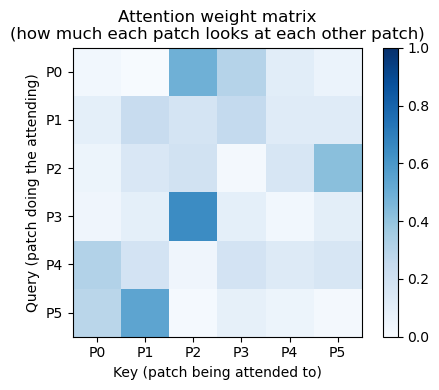

Input shape:   torch.Size([6, 8])  (6 patches × 8 dims)
Output shape:  torch.Size([6, 8])  (same — each patch is now enriched with context from all others)
Each row of the weight matrix sums to 1: [1. 1. 1. 1. 1. 1.]


In [12]:
# --- Minimal self-attention from scratch ---
# This shows the exact computation, not a full transformer layer.

def self_attention(Q, K, V):
    """
    Q, K, V: tensors of shape (sequence_length, dim)
    Returns: attended values of shape (sequence_length, dim)
             and attention weights of shape (sequence_length, sequence_length)
    """
    d = Q.shape[-1]  # embedding dimension
    
    # Compute raw attention scores: how much does each token attend to each other token
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d ** 0.5)  # shape: (seq_len, seq_len)
    
    # Softmax so weights sum to 1 across the sequence
    weights = F.softmax(scores, dim=-1)  # shape: (seq_len, seq_len)
    
    # Weighted sum of values
    output = torch.matmul(weights, V)  # shape: (seq_len, dim)
    
    return output, weights


# Simulate 6 patches with 8-dimensional embeddings
seq_len, dim = 6, 8
Q = torch.randn(seq_len, dim)  # each patch's query
K = torch.randn(seq_len, dim)  # each patch's key
V = torch.randn(seq_len, dim)  # each patch's value

output, weights = self_attention(Q, K, V)

# Visualise the attention weight matrix: rows=queries, cols=keys
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights.detach().numpy(), cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xlabel('Key (patch being attended to)')
ax.set_ylabel('Query (patch doing the attending)')
ax.set_title('Attention weight matrix\n(how much each patch looks at each other patch)')
ax.set_xticks(range(seq_len)); ax.set_xticklabels([f'P{i}' for i in range(seq_len)])
ax.set_yticks(range(seq_len)); ax.set_yticklabels([f'P{i}' for i in range(seq_len)])
plt.tight_layout()
plt.show()

print(f"Input shape:   {Q.shape}  (6 patches × 8 dims)")
print(f"Output shape:  {output.shape}  (same — each patch is now enriched with context from all others)")
print(f"Each row of the weight matrix sums to 1: {weights.sum(dim=-1).detach().numpy().round(3)}")

---
## 3. Vision Transformer (ViT) — images as sequences of patches

ViT applies the transformer architecture to images with a simple trick: **split the image into patches and treat each patch as a token** (like a word in a sentence).

```
Input image (224×224)
    ↓  split into 16×16 patches
196 patches  (224/16 = 14 patches per side → 14×14 = 196 patches)
    ↓  flatten each patch → linear projection → embedding
196 patch embeddings  (each is a vector of size 768 for ViT-B)
    ↓  prepend [CLS] token  (a learnable token that aggregates global information)
197 tokens
    ↓  add positional encodings  (tells the model where each patch is in the image)
    ↓  feed through N transformer blocks (each with multi-head self-attention)
    ↓  take [CLS] token output as the image feature vector
768-dim feature vector  ←  this is what you use for your regression head
```

### The [CLS] token
This special token has no corresponding image region.  
Through attention, it learns to aggregate information from all 196 patches.  
Its output embedding represents the whole image — analogous to ResNet's global average pooled vector.

### Positional encoding
Unlike CNNs, a transformer has no built-in sense of spatial structure.  
Positional encodings are added to patch embeddings to inject location information:  
patch #1 is top-left, patch #196 is bottom-right, etc.

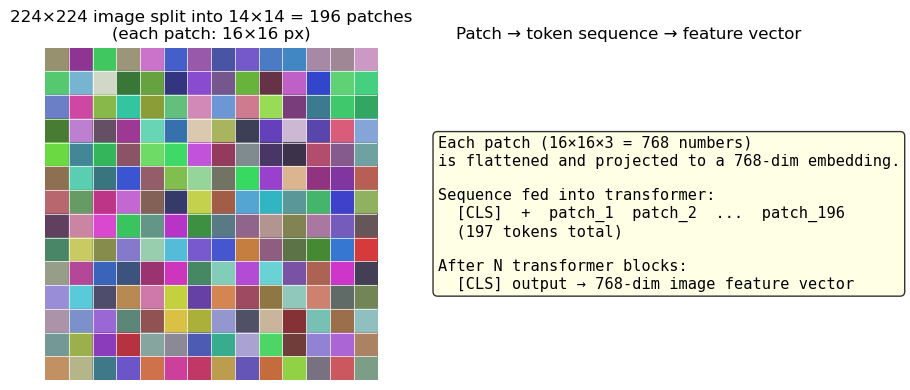

In [13]:
# --- Visualise the patch-splitting step ---

# Create a synthetic colourful image to make patch boundaries visible
img_size = 224
patch_size = 16
n_patches_side = img_size // patch_size  # 14 patches per side

# Each patch gets a random colour so boundaries are obvious
patch_colours = np.random.randint(50, 220, size=(n_patches_side, n_patches_side, 3), dtype=np.uint8)
image_grid = np.repeat(np.repeat(patch_colours, patch_size, axis=0), patch_size, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: the image with patch grid overlay
axes[0].imshow(image_grid)
for i in range(1, n_patches_side):  # draw grid lines
    axes[0].axhline(i * patch_size - 0.5, color='white', linewidth=0.5)
    axes[0].axvline(i * patch_size - 0.5, color='white', linewidth=0.5)
axes[0].set_title(f'224×224 image split into {n_patches_side}×{n_patches_side} = {n_patches_side**2} patches\n(each patch: {patch_size}×{patch_size} px)')
axes[0].axis('off')

# Right: show what happens to the tokens sequence
axes[1].axis('off')
text = (
    f"Each patch ({patch_size}×{patch_size}×3 = {patch_size*patch_size*3} numbers)\n"
    f"is flattened and projected to a 768-dim embedding.\n\n"
    f"Sequence fed into transformer:\n"
    f"  [CLS]  +  patch_1  patch_2  ...  patch_{n_patches_side**2}\n"
    f"  ({1 + n_patches_side**2} tokens total)\n\n"
    f"After N transformer blocks:\n"
    f"  [CLS] output → 768-dim image feature vector"
)
axes[1].text(0.05, 0.5, text, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].set_title('Patch → token sequence → feature vector')

plt.tight_layout()
plt.show()

---
## 4. ViT Feature Extraction Demo

Using the same pattern as in `cv_example.ipynb`: load pretrained ViT-B/16, remove the classifier head,  
use as a frozen feature extractor.

In [14]:
# --- Load pretrained ViT-B/16 ---
# ViT-B/16 = Base model, 16×16 patch size
# Pretrained on ImageNet-21k then fine-tuned on ImageNet-1k

vit = models.vit_b_16(weights='DEFAULT')

# Print top-level structure
print("ViT-B/16 structure (top level):")
for name, module in vit.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:20s}  ({params:,} parameters)")

print(f"\nTotal parameters: {sum(p.numel() for p in vit.parameters()):,}")
print("\nThe 'heads' layer is the ImageNet classifier — we will replace it with Identity.")

ViT-B/16 structure (top level):
  conv_proj             (590,592 parameters)
  encoder               (85,207,296 parameters)
  heads                 (769,000 parameters)

Total parameters: 86,567,656

The 'heads' layer is the ImageNet classifier — we will replace it with Identity.


In [15]:
# --- Build a frozen ViT feature extractor ---

# Remove the classifier head; the model now outputs the raw [CLS] token embedding
vit_extractor = models.vit_b_16(weights='DEFAULT')
vit_extractor.heads = nn.Identity()  # ViT uses 'heads' instead of ResNet's 'fc'

# Freeze all parameters
for param in vit_extractor.parameters():
    param.requires_grad = False

vit_extractor.eval()
vit_extractor = vit_extractor.to(device)

# ViT requires the same ImageNet normalisation as ResNet
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Run on a dummy image matching your reprojected intersection images (1500×880)
dummy_image = Image.fromarray((np.random.rand(880, 1500, 3) * 255).astype(np.uint8))
img_tensor = preprocess(dummy_image).unsqueeze(0).to(device)

with torch.no_grad():
    vit_features = vit_extractor(img_tensor)

print(f"Input image size:      {dummy_image.size}")
print(f"After preprocessing:   {img_tensor.shape}")
print(f"ViT feature vector:    {vit_features.shape}  (768-dim [CLS] token)")
print(f"\nCompare to ResNet-50:  2048-dim — ViT is smaller but typically more expressive.")

Input image size:      (1500, 880)
After preprocessing:   torch.Size([1, 3, 224, 224])
ViT feature vector:    torch.Size([1, 768])  (768-dim [CLS] token)

Compare to ResNet-50:  2048-dim — ViT is smaller but typically more expressive.


---
## 5. The Problem with Supervised ViTs on Small Datasets

ViT was originally trained on **ImageNet-21k** (14 million images). The authors noted in their paper:

> *"When trained on mid-sized datasets such as ImageNet without strong regularisation, ViT yields modest accuracy, slightly below ResNets of comparable size."*

Why? CNNs have a built-in structural assumption: nearby pixels are related. This is a useful shortcut that helps CNNs learn from less data. Transformers have **no such assumption** — they have to learn spatial structure entirely from data.

**For your thesis (~400 intersections):**
- A frozen ViT backbone is fine (you're just using its pretrained features)
- **Fine-tuning** a ViT on 400 samples is risky — too many parameters to reliably update
- This is exactly the motivation for **self-supervised pretraining** (next section)

```
Supervised ViT training:
  image → model → "is this a cat or a dog?"  (needs many labelled images)

Self-supervised ViT training (DINO):
  image → model → internal consistency tasks  (no labels needed, can train on millions of images)
```

---
## 6. Self-Supervised Learning — Learning Without Labels

The key insight: you can train a powerful visual model **without any human labels** if you design the right training objective.

### How it works (the DINO idea)

Take one image. Create two different augmented views of it — different crops, colours, flips.  
Train a **student** network to produce the same output as a **teacher** network, given these different views.

```
Image
  ├── augmented view 1 → Student network → embedding A
  └── augmented view 2 → Teacher network → embedding B
                                                        ↑
                         Loss: make A and B similar  (teacher is a slow-moving average of student)
```

To match the teacher, the student has to learn *what is structurally consistent across views* —  
i.e., the semantic content of the image, not surface details like lighting or exact crop position.

**Why this produces better features than supervised training:**  
Supervised training teaches the model to distinguish 1000 ImageNet categories.  
Self-supervised training teaches the model to understand the full semantic structure of every image,  
which is a much richer signal.

---
## 7. DINOv2 — What It Is and Why It Is Different

**DINOv2** (Meta, 2023) is a ViT trained with a refined version of self-supervised DINO training  
on **142 million curated images** (LVD-142M dataset — diverse, including many outdoor/urban scenes).

### What makes DINOv2 stand out:

| Property | Details |
|---|---|
| **No task-specific training** | Trained purely on visual consistency — no labels at all |
| **General features** | Works well as a frozen backbone on tasks it was never trained for |
| **Spatial awareness** | Patch tokens retain local information (useful for detection/segmentation), unlike ViT's [CLS] only |
| **Emergent segmentation** | Attention maps naturally highlight semantically coherent regions (roads, buildings, sky) without ever being trained on segmentation |
| **Strong on small datasets** | Because the backbone is frozen and already very expressive, you need fewer labeled examples |

### Available sizes:
| Model | Embedding dim | Parameters | Recommendation |
|---|---|---|---|
| `dinov2_vits14` | 384 | 21M | **Start here** — fast, strong |
| `dinov2_vitb14` | 768 | 86M | Better accuracy, slower |
| `dinov2_vitl14` | 1024 | 307M | Best accuracy, needs GPU |
| `dinov2_vitg14` | 1536 | 1.1B | Research use, very slow |

Note: patch size is **14** (not 16), so a 224×224 image → 16×16 = **256 patches**.

**For your thesis: `dinov2_vits14`** is the right balance — 21M parameters, 384-dim features,  
runs quickly on CPU, and produces state-of-the-art frozen features.

In [16]:
# --- Load DINOv2-Small via torch.hub ---
# This downloads the model weights from Meta's repository (~85 MB)

dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2.eval()

# Freeze all parameters — we use it purely as a feature extractor
for param in dinov2.parameters():
    param.requires_grad = False

dinov2 = dinov2.to(device)

print("DINOv2-Small loaded.")
print(f"Parameters: {sum(p.numel() for p in dinov2.parameters()):,}")
print(f"Output embedding dimension: 384")
print(f"Patch size: 14×14 px  →  224/14 = 16 patches per side  →  256 patch tokens + 1 [CLS] token")

Using cache found in C:\Users\Thijs/.cache\torch\hub\facebookresearch_dinov2_main


DINOv2-Small loaded.
Parameters: 22,056,576
Output embedding dimension: 384
Patch size: 14×14 px  →  224/14 = 16 patches per side  →  256 patch tokens + 1 [CLS] token


In [17]:
# --- DINOv2 preprocessing ---
# Same ImageNet normalisation as before; input size must be a multiple of patch_size=14
# 224 = 16×14 — the standard choice

dino_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Run on a dummy image
dummy_image = Image.fromarray((np.random.rand(880, 1500, 3) * 255).astype(np.uint8))
img_tensor = dino_preprocess(dummy_image).unsqueeze(0).to(device)

with torch.no_grad():
    dino_features = dinov2(img_tensor)  # returns [CLS] token by default

print(f"Input image size:       {dummy_image.size}")
print(f"DINOv2 feature vector:  {dino_features.shape}  (384-dim [CLS] token)")
print()

# Summary comparison with the other backbones from cv_example.ipynb
print("Backbone comparison:")
print(f"  ResNet-50:       2048-dim  |  25M params  |  supervised ImageNet")
print(f"  ViT-B/16:         768-dim  |  86M params  |  supervised ImageNet-21k")
print(f"  DINOv2-Small:     384-dim  |  21M params  |  self-supervised LVD-142M")
print()
print("DINOv2 has the SMALLEST output and fewest parameters, but typically the strongest frozen features.")

Input image size:       (1500, 880)
DINOv2 feature vector:  torch.Size([1, 384])  (384-dim [CLS] token)

Backbone comparison:
  ResNet-50:       2048-dim  |  25M params  |  supervised ImageNet
  ViT-B/16:         768-dim  |  86M params  |  supervised ImageNet-21k
  DINOv2-Small:     384-dim  |  21M params  |  self-supervised LVD-142M

DINOv2 has the SMALLEST output and fewest parameters, but typically the strongest frozen features.


---
## 8. Patch Tokens vs [CLS] Token

DINOv2 (like all ViTs) produces two types of output:

| Output | Shape | Contains |
|---|---|---|
| **[CLS] token** | `(1, 384)` | Global image summary — use this for classification/regression |
| **Patch tokens** | `(256, 384)` | One vector per 14×14 patch — spatial features |

For your thesis (predicting a per-intersection score), the **[CLS] token** is what you want.  

But you can also average the patch tokens (`mean pooling`) as an alternative — sometimes slightly better.

In [18]:
# --- Access both [CLS] and patch tokens from DINOv2 ---
# forward_features() returns a dict with both, unlike the default forward() which returns only [CLS]

with torch.no_grad():
    output = dinov2.forward_features(img_tensor)

cls_token    = output['x_norm_clstoken']   # shape: (1, 384) — global summary
patch_tokens = output['x_norm_patchtokens'] # shape: (1, 256, 384) — spatial features

print(f"[CLS] token shape:    {cls_token.shape}")
print(f"Patch tokens shape:   {patch_tokens.shape}  (1 image × 256 patches × 384 dims)")

# Option 1: use [CLS] token directly
feature_cls = cls_token.squeeze(0)                         # (384,)

# Option 2: mean-pool over patch tokens
feature_patch_mean = patch_tokens.squeeze(0).mean(dim=0)   # (384,)

# Option 3: concatenate both (richer but doubles the dimension)
feature_concat = torch.cat([feature_cls, feature_patch_mean], dim=-1)  # (768,)

print(f"\nFeature options:")
print(f"  [CLS] only:              {feature_cls.shape}")
print(f"  Patch mean only:         {feature_patch_mean.shape}")
print(f"  CLS + patch mean concat: {feature_concat.shape}")
print("\nRecommendation: start with [CLS] only. Try concat if performance is weak.")

[CLS] token shape:    torch.Size([1, 384])
Patch tokens shape:   torch.Size([1, 256, 384])  (1 image × 256 patches × 384 dims)

Feature options:
  [CLS] only:              torch.Size([384])
  Patch mean only:         torch.Size([384])
  CLS + patch mean concat: torch.Size([768])

Recommendation: start with [CLS] only. Try concat if performance is weak.


---
## 9. DINOv2 Attention Maps — What the Model Focuses On

One of DINOv2's most striking properties: its **self-attention maps naturally segment the image**  
into semantically meaningful regions — without ever being trained on segmentation.

This tells you *what the model is paying attention to* when building its feature vector.  
For intersection images you would expect high attention on: road surface, lane markings, signs, curbs.

We visualise the attention from the **[CLS] token to all patch tokens** in the last transformer block.  
This shows which patches the model considers most informative for the global image summary.

Attention tensor shape: torch.Size([1, 6, 257, 257])
  batch=1, heads=6, tokens=257 (256 patches + 1 [CLS])


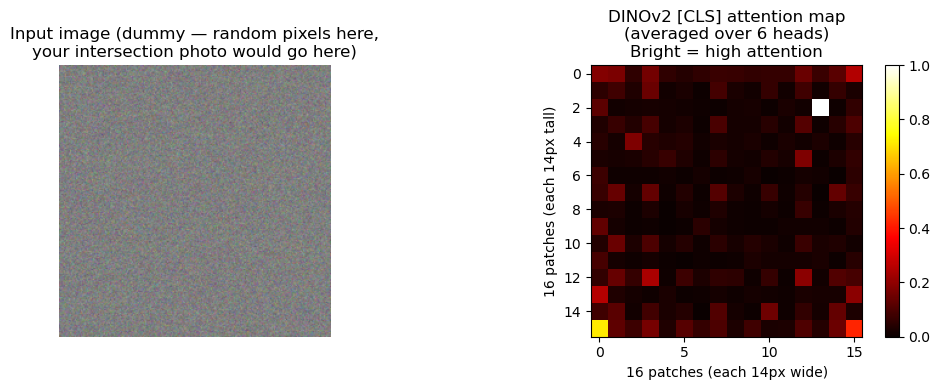

On a real intersection photo, bright regions would highlight semantically relevant areas.
This is useful for your thesis: you can show WHAT the model focuses on, not just the score.


In [19]:
# --- Extract and visualise DINOv2 attention maps ---
# DINOv2 does not expose attention weights directly, so we use a forward hook on the
# qkv projection layer inside the last transformer block.
# From the qkv output we can reconstruct Q and K and recompute attention ourselves.

def get_dino_attention(model, img_tensor):
    """
    Extract self-attention weights from the last transformer block of a DINOv2 model.
    Uses a forward hook on the qkv linear layer to capture Q and K before they are used.
    Returns tensor of shape (batch, n_heads, n_tokens, n_tokens).
    """
    saved = {}
    last_attn = model.blocks[-1].attn  # attention module of the final transformer block

    def qkv_hook(module, input, output):
        B, N, _ = output.shape
        num_heads = last_attn.num_heads
        head_dim  = output.shape[-1] // (3 * num_heads)  # 384 / (3*6) = 64 for DINOv2-S

        # Reshape flat qkv output → separate Q, K, V tensors
        qkv = output.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
        q, k, _ = qkv.unbind(0)  # each: (B, num_heads, N, head_dim)

        # Apply per-head layer norms if present — only newer DINOv2 variants
        # (e.g. register-token models) have q_norm / k_norm; skip silently if absent
        if hasattr(last_attn, 'q_norm'):
            q = last_attn.q_norm(q)
        if hasattr(last_attn, 'k_norm'):
            k = last_attn.k_norm(k)

        # Scaled dot-product attention weights (no dropout — we just want the weights)
        scale = head_dim ** -0.5
        attn  = (q @ k.transpose(-2, -1)) * scale
        attn  = attn.softmax(dim=-1)  # shape: (B, n_heads, N, N)

        saved['attn'] = attn.detach()

    hook = last_attn.qkv.register_forward_hook(qkv_hook)
    with torch.no_grad():
        model(img_tensor)  # forward pass triggers the hook
    hook.remove()  # always remove the hook after use

    return saved['attn']


# Run the attention extraction — shape: (1, n_heads, n_tokens, n_tokens)
attn = get_dino_attention(dinov2, img_tensor)

print(f"Attention tensor shape: {attn.shape}")
print(f"  batch=1, heads={attn.shape[1]}, tokens={attn.shape[2]} (256 patches + 1 [CLS])")

# Extract attention FROM the [CLS] token (index 0) TO all patch tokens (indices 1:)
# Average across all attention heads
n_heads         = attn.shape[1]
patch_size_dino = 14
n_patches_side  = 224 // patch_size_dino  # 16 patches per side

cls_attention      = attn[0, :, 0, 1:]           # shape: (n_heads, n_patches=256)
cls_attention_mean = cls_attention.mean(dim=0)    # average over heads → (256,)

# Reshape flat patch attention to 2D spatial map
attention_map = cls_attention_mean.reshape(n_patches_side, n_patches_side).cpu().numpy()

# Normalise to [0, 1] for display
attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

# Visualise: attention map alongside the input image
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(dummy_image.resize((224, 224)))
axes[0].set_title('Input image (dummy — random pixels here,\nyour intersection photo would go here)')
axes[0].axis('off')

im = axes[1].imshow(attention_map, cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_title(f'DINOv2 [CLS] attention map\n(averaged over {n_heads} heads)\nBright = high attention')
axes[1].set_xlabel(f'{n_patches_side} patches (each {patch_size_dino}px wide)')
axes[1].set_ylabel(f'{n_patches_side} patches (each {patch_size_dino}px tall)')

plt.tight_layout()
plt.show()

print("On a real intersection photo, bright regions would highlight semantically relevant areas.")
print("This is useful for your thesis: you can show WHAT the model focuses on, not just the score.")

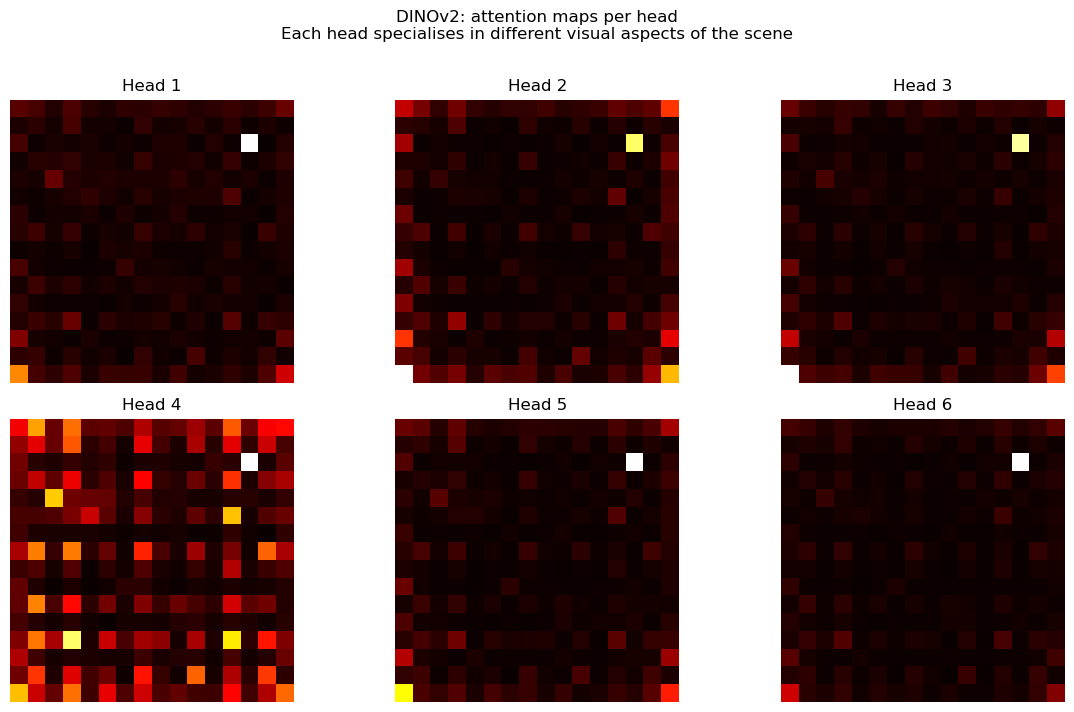

On real images: some heads focus on foreground objects, others on background, texture, etc.


In [20]:
# --- Show per-head attention maps (each head focuses on different aspects) ---

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for head_idx in range(min(6, n_heads)):  # show first 6 heads
    head_attn = attn[0, head_idx, 0, 1:]  # [CLS] → patches for this head
    head_map  = head_attn.reshape(n_patches_side, n_patches_side).cpu().numpy()
    head_map  = (head_map - head_map.min()) / (head_map.max() - head_map.min())
    
    axes[head_idx].imshow(head_map, cmap='hot', interpolation='nearest')
    axes[head_idx].set_title(f'Head {head_idx + 1}')
    axes[head_idx].axis('off')

plt.suptitle('DINOv2: attention maps per head\nEach head specialises in different visual aspects of the scene', y=1.01)
plt.tight_layout()
plt.show()
print("On real images: some heads focus on foreground objects, others on background, texture, etc.")

---
## 10. Which Backbone to Use for Your Thesis

### Summary comparison

| Backbone | Feature dim | Params | Training | Frozen quality | Fine-tune risk | Recommended? |
|---|---|---|---|---|---|---|
| ResNet-50 | 2048 | 25M | Supervised ImageNet | Good | Low | ✓ Baseline |
| EfficientNet-B0 | 1280 | 5M | Supervised ImageNet | Good | Low | ✓ Alternative CNN |
| ViT-B/16 | 768 | 86M | Supervised ImageNet-21k | Good | High | Use frozen only |
| **DINOv2-S** | **384** | **21M** | **Self-sup LVD-142M** | **Excellent** | **Low** | **✓ Recommended** |

### Suggested workflow

```
Step 1: ResNet-50 frozen + regression head     ← your cv_example.ipynb baseline
        → establish a working pipeline + evaluation loop

Step 2: swap backbone to DINOv2-Small          ← just change one line
        → compare val MAE/R² — likely better

Step 3 (optional): fine-tune last 2 ViT blocks of DINOv2
        → lower learning rate (1e-5), early stopping, check for overfitting

Step 4: attention map analysis
        → visualise what the model focuses on in your intersection photos
        → useful for thesis discussion: does it match road safety intuition?
```

### The one-line backbone swap
```python
# ResNet (from cv_example.ipynb)
backbone = models.resnet50(weights='DEFAULT')
backbone.fc = nn.Identity()
feature_dim = 2048

# DINOv2 — swap these three lines, everything else stays the same
backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
# (no head to remove — DINOv2 already outputs [CLS] directly)
feature_dim = 384
```

In [21]:
# --- Final demo: DINOv2 + regression head, end-to-end on a batch ---
# This mirrors the full pipeline from cv_example.ipynb but with the DINOv2 backbone.

class SafetyScoreHeadDINO(nn.Module):
    """Same regression head as in cv_example.ipynb, adapted for 384-dim DINOv2 features."""
    def __init__(self, feature_dim=384, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)


head = SafetyScoreHeadDINO(feature_dim=384).to(device)

# Simulate a batch of 4 intersections × 3 legs each
batch_intersections = 4
legs_per_intersection = 3

# Extract DINOv2 features for each leg image
all_features = []
for i in range(batch_intersections):
    leg_feats = []
    for j in range(legs_per_intersection):
        dummy_leg = Image.fromarray((np.random.rand(880, 1500, 3) * 255).astype(np.uint8))
        tensor = dino_preprocess(dummy_leg).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = dinov2(tensor).squeeze(0)  # (384,)
        leg_feats.append(feat)
    
    # Mean-pool across legs → one vector per intersection
    intersection_feat = torch.stack(leg_feats).mean(dim=0)  # (384,)
    all_features.append(intersection_feat)

# Stack into batch and run through regression head
feature_batch = torch.stack(all_features)  # (4, 384)
predictions   = head(feature_batch)         # (4,)
fake_labels   = torch.rand(batch_intersections).to(device) * 10

loss = nn.MSELoss()(predictions, fake_labels)

print(f"Batch of {batch_intersections} intersections × {legs_per_intersection} legs")
print(f"Feature batch shape:  {feature_batch.shape}")
print(f"Predictions:          {predictions.detach().cpu().numpy().round(3)}")
print(f"Fake labels:          {fake_labels.cpu().numpy().round(3)}")
print(f"MSE loss:             {loss.item():.4f}")
print("\nPipeline is identical to cv_example.ipynb — only the backbone and feature_dim changed.")

Batch of 4 intersections × 3 legs
Feature batch shape:  torch.Size([4, 384])
Predictions:          [-0.108 -0.036 -0.994 -0.533]
Fake labels:          [3.844 6.276 1.356 5.998]
MSE loss:             25.9103

Pipeline is identical to cv_example.ipynb — only the backbone and feature_dim changed.
